In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Load Phase 3 Summary Output
df_p3 = pd.read_csv(
    "portfolio_phase3_output(10).csv", parse_dates=["Date"], index_col="Date"
)

# Extract daily portfolio return series & daily dollar P&L
returns = df_p3["Daily_Return"]
pnl = df_p3["Daily_PnL"]
portfolio_val = df_p3["Portfolio_Value"]

# Parameters
windows = [250, 500, 750]
conf_levels = [0.95, 0.99, 0.995]


# 2. Base Functions for VaR and ES
def calc_var_es(series, confidence_level):
    """Calculates empirical VaR and Expected Shortfall for a return or P&L series.

    Returns positive numbers representing the dollar/percent LOSS threshold.
    """
    alpha = 1.0 - confidence_level
    # Percentile quantile representing the loss tail
    var_threshold = np.percentile(series, alpha * 100)

    # Expected Shortfall: mean of all returns/losses strictly worse than VaR
    tail_losses = series[series <= var_threshold]
    expected_shortfall = (
        tail_losses.mean() if len(tail_losses) > 0 else var_threshold
    )

    # Convert to positive values representing LOSS magnitude
    return -var_threshold, -expected_shortfall


# 3. Static Multi-Window / Multi-Confidence Summary
summary_records = []

for w in windows:
    recent_pnl = pnl.iloc[-w:]
    for cl in conf_levels:
        var_dollar, es_dollar = calc_var_es(recent_pnl, cl)
        summary_records.append(
            {
                "Window_Days": w,
                "Confidence_Level": f"{cl*100}%",
                "VaR_Dollar ($)": round(var_dollar, 2),
                "Expected_Shortfall ($)": round(es_dollar, 2),
            }
        )

var_es_summary = pd.DataFrame(summary_records)
print("--- Historical VaR & Expected Shortfall Summary ---")
print(var_es_summary.to_string(index=False))

--- Historical VaR & Expected Shortfall Summary ---
 Window_Days Confidence_Level  VaR_Dollar ($)  Expected_Shortfall ($)
         250            95.0%         8122.33                10130.84
         250            99.0%        11265.69                11997.05
         250            99.5%        11904.94                12288.66
         500            95.0%         8227.59                11413.68
         500            99.0%        12068.79                17193.62
         500            99.5%        13372.13                20131.85
         750            95.0%         6759.43                10056.58
         750            99.0%        11265.69                15140.14
         750            99.5%        12652.37                18363.76


In [2]:
def compute_rolling_risk_metrics(series, window, confidence_level):
    alpha = 1.0 - confidence_level

    def get_var(x):
        return -np.percentile(x, alpha * 100)

    def get_es(x):
        v = np.percentile(x, alpha * 100)
        tail = x[x <= v]
        return -tail.mean() if len(tail) > 0 else -v

    rolling_var = series.rolling(window=window).apply(
        get_var, raw=False
    )
    rolling_es = series.rolling(window=window).apply(
        get_es, raw=False
    )

    return rolling_var, rolling_es


# Compute rolling metrics for 250-day window at 95% and 99%
rolling_var_95, rolling_es_95 = compute_rolling_risk_metrics(
    pnl, window=250, confidence_level=0.95
)
rolling_var_99, rolling_es_99 = compute_rolling_risk_metrics(
    pnl, window=250, confidence_level=0.99
)

# Export Rolling Risk Metrics to CSV
rolling_df = pd.DataFrame(
    {
        "Rolling_VaR_95": rolling_var_95,
        "Rolling_ES_95": rolling_es_95,
        "Rolling_VaR_99": rolling_var_99,
        "Rolling_ES_99": rolling_es_99,
    },
    index=pnl.index,
)

rolling_df.to_csv("rolling_var_es_phase4.csv")

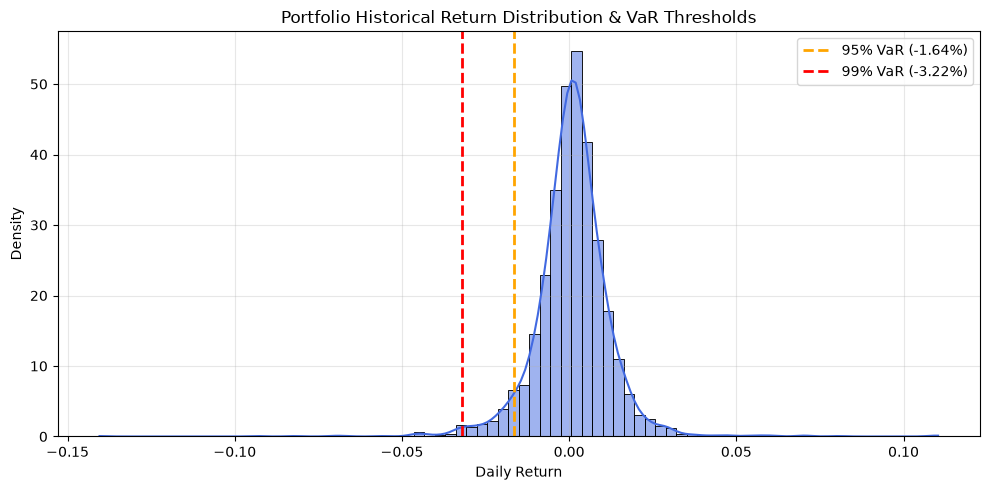

In [3]:
plt.figure(figsize=(10, 5))
sns.histplot(returns, bins=80, kde=True, color="royalblue", stat="density")

# Calculate return-based VaR thresholds
var_95_ret, _ = calc_var_es(returns, 0.95)
var_99_ret, _ = calc_var_es(returns, 0.99)

plt.axvline(
    -var_95_ret,
    color="orange",
    linestyle="--",
    linewidth=2,
    label=f"95% VaR ({-var_95_ret:.2%})",
)
plt.axvline(
    -var_99_ret,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"99% VaR ({-var_99_ret:.2%})",
)

plt.title("Portfolio Historical Return Distribution & VaR Thresholds")
plt.xlabel("Daily Return")
plt.ylabel("Density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

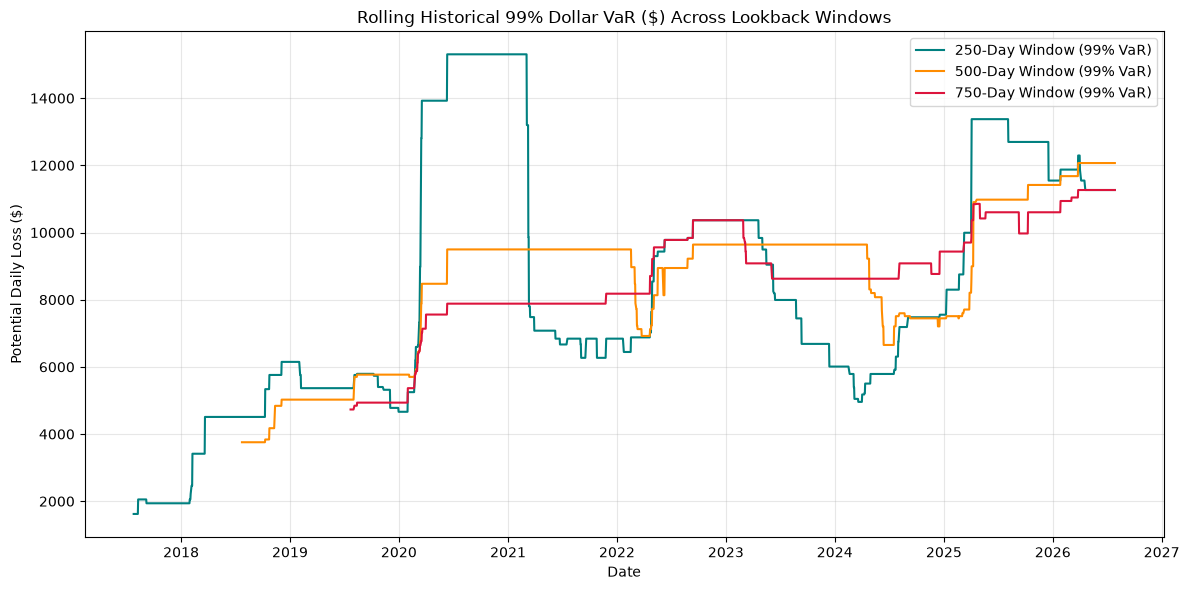

In [4]:
plt.figure(figsize=(12, 6))

for w, col in zip(windows, ["teal", "darkorange", "crimson"]):
    r_var, _ = compute_rolling_risk_metrics(pnl, window=w, confidence_level=0.99)
    plt.plot(r_var.index, r_var, label=f"{w}-Day Window (99% VaR)", color=col, lw=1.5)

plt.title("Rolling Historical 99% Dollar VaR ($) Across Lookback Windows")
plt.xlabel("Date")
plt.ylabel("Potential Daily Loss ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

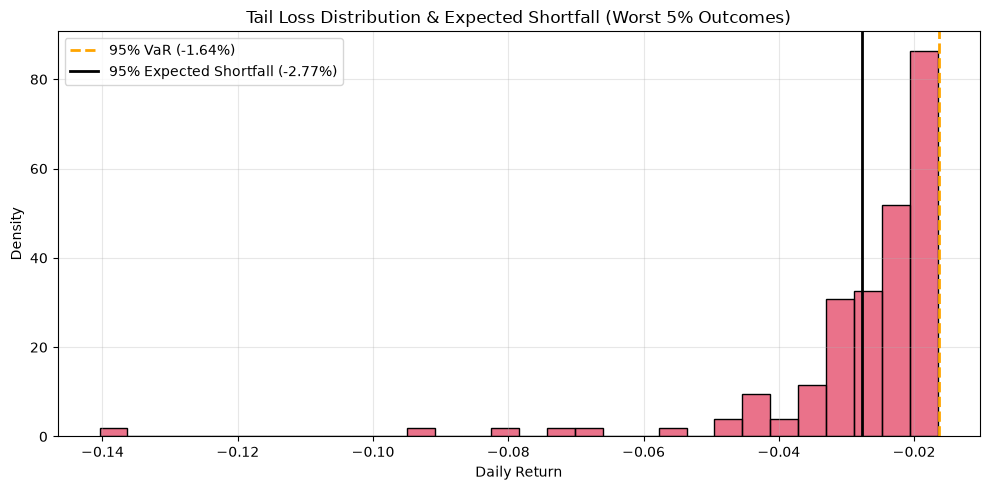

In [5]:
plt.figure(figsize=(10, 5))

# Focus on daily return tail (worst 5% outcomes)
tail_cutoff = -var_95_ret
tail_returns = returns[returns <= tail_cutoff]

sns.histplot(
    tail_returns, bins=30, color="crimson", kde=False, stat="density", alpha=0.6
)
_, es_95_ret = calc_var_es(returns, 0.95)

plt.axvline(
    tail_cutoff,
    color="orange",
    linestyle="--",
    linewidth=2,
    label=f"95% VaR ({-var_95_ret:.2%})",
)
plt.axvline(
    -es_95_ret,
    color="black",
    linestyle="-",
    linewidth=2,
    label=f"95% Expected Shortfall ({-es_95_ret:.2%})",
)

plt.title("Tail Loss Distribution & Expected Shortfall (Worst 5% Outcomes)")
plt.xlabel("Daily Return")
plt.ylabel("Density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

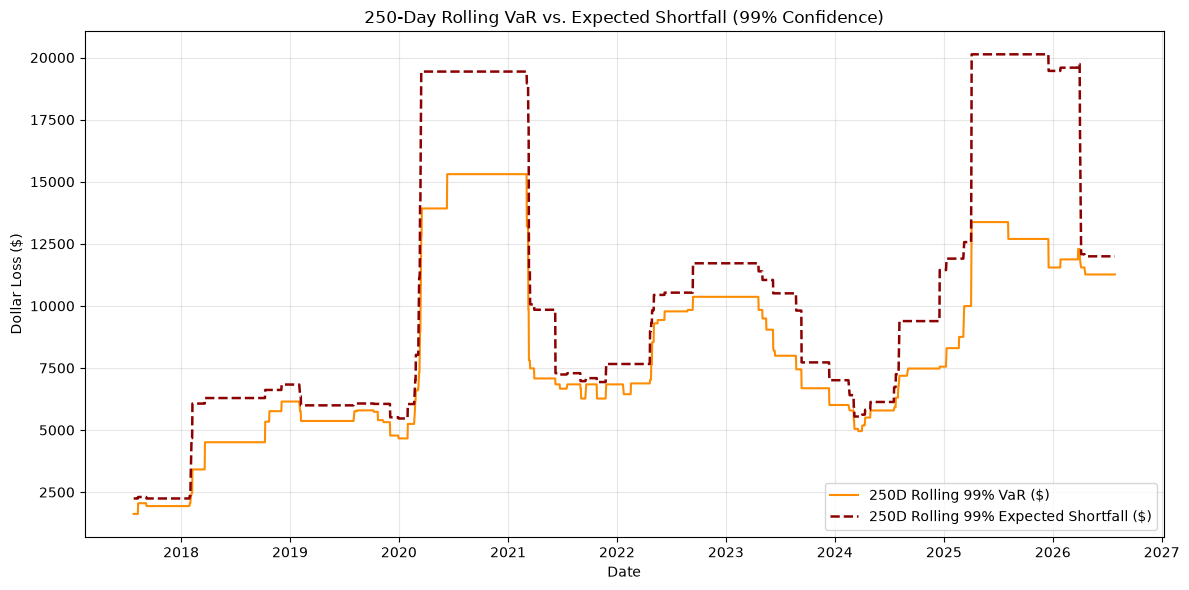

In [6]:
plt.figure(figsize=(12, 6))

plt.plot(
    rolling_var_99.index,
    rolling_var_99,
    label="250D Rolling 99% VaR ($)",
    color="darkorange",
    lw=1.5,
)
plt.plot(
    rolling_es_99.index,
    rolling_es_99,
    label="250D Rolling 99% Expected Shortfall ($)",
    color="darkred",
    lw=1.8,
    linestyle="--",
)

plt.title("250-Day Rolling VaR vs. Expected Shortfall (99% Confidence)")
plt.xlabel("Date")
plt.ylabel("Dollar Loss ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def run_phase_4():
  print("==================================================")
  print("      RUNNING PHASE 4: HISTORICAL SIMULATION VaR   ")
  print("==================================================")

  # ---------------------------------------------------------
  # 1. Load Data from Phase 3 Output
  # ---------------------------------------------------------
  input_file = "portfolio_phase3_output(10).csv"
  if not os.path.exists(input_file):
    raise FileNotFoundError(
        f"'{input_file}' not found! Please ensure Phase 3 output exists."
    )

  df_p3 = pd.read_csv(input_file, parse_dates=["Date"], index_col="Date")
  returns = df_p3["Daily_Return"]
  pnl = df_p3["Daily_PnL"]

  windows = [250, 500, 750]
  conf_levels = [0.95, 0.99, 0.995]

  # Helper: Empirical VaR and ES calculation
  def calc_var_es(series, confidence_level):
    alpha = 1.0 - confidence_level
    var_threshold = np.percentile(series, alpha * 100)
    tail_losses = series[series <= var_threshold]
    expected_shortfall = (
        tail_losses.mean() if len(tail_losses) > 0 else var_threshold
    )
    return -var_threshold, -expected_shortfall

  # ---------------------------------------------------------
  # 2. Static Multi-Window & Multi-Confidence VaR/ES Summary
  # ---------------------------------------------------------
  summary_records = []
  for w in windows:
    recent_pnl = pnl.iloc[-w:]
    for cl in conf_levels:
      var_dollar, es_dollar = calc_var_es(recent_pnl, cl)
      summary_records.append({
          "Window_Days": w,
          "Confidence_Level": f"{cl*100}%",
          "VaR_Dollar ($)": round(var_dollar, 2),
          "Expected_Shortfall ($)": round(es_dollar, 2),
      })

  var_es_summary = pd.DataFrame(summary_records)
  var_es_summary.to_csv("var_es_summary_phase4(10).csv", index=False)
  print(" [✓] Saved VaR/ES Summary -> var_es_summary_phase4(10).csv")

  # ---------------------------------------------------------
  # 3. Rolling VaR & ES Calculations
  # ---------------------------------------------------------
  def compute_rolling_risk_metrics(series, window, confidence_level):
    alpha = 1.0 - confidence_level

    def get_var(x):
      return -np.percentile(x, alpha * 100)

    def get_es(x):
      v = np.percentile(x, alpha * 100)
      tail = x[x <= v]
      return -tail.mean() if len(tail) > 0 else -v

    rolling_var = series.rolling(window=window).apply(get_var, raw=False)
    rolling_es = series.rolling(window=window).apply(get_es, raw=False)
    return rolling_var, rolling_es

  print(" Calculating rolling metrics... (this may take a few seconds)")
  rolling_var_95, rolling_es_95 = compute_rolling_risk_metrics(
      pnl, window=250, confidence_level=0.95
  )
  rolling_var_99, rolling_es_99 = compute_rolling_risk_metrics(
      pnl, window=250, confidence_level=0.99
  )

  rolling_df = pd.DataFrame(
      {
          "Rolling_VaR_95": rolling_var_95,
          "Rolling_ES_95": rolling_es_95,
          "Rolling_VaR_99": rolling_var_99,
          "Rolling_ES_99": rolling_es_99,
      },
      index=pnl.index,
  )
  rolling_df.to_csv("rolling_var_es_phase4(10).csv")
  print(" [✓] Saved Rolling Metrics -> rolling_var_es_phase4(10).csv")

  # ---------------------------------------------------------
  # 4. Generate & Save Charts as PNG Images
  # ---------------------------------------------------------
  sns.set_theme(style="whitegrid")

  # Chart 1: Return Distribution & VaR
  plt.figure(figsize=(10, 5))
  sns.histplot(returns, bins=80, kde=True, color="royalblue", stat="density")
  var_95_ret, _ = calc_var_es(returns, 0.95)
  var_99_ret, _ = calc_var_es(returns, 0.99)
  plt.axvline(
      -var_95_ret,
      color="orange",
      linestyle="--",
      linewidth=2,
      label=f"95% VaR ({-var_95_ret:.2%})",
  )
  plt.axvline(
      -var_99_ret,
      color="red",
      linestyle="--",
      linewidth=2,
      label=f"99% VaR ({-var_99_ret:.2%})",
  )
  plt.title("Portfolio Historical Return Distribution & VaR Thresholds")
  plt.xlabel("Daily Return")
  plt.ylabel("Density")
  plt.legend()
  plt.tight_layout()
  plt.savefig("chart1_return_distribution_var(10).png", dpi=300)
  plt.close()
  print(" [✓] Saved Chart 1 -> chart1_return_distribution_var(10).png")

  # Chart 2: Rolling VaR Across Windows
  plt.figure(figsize=(12, 6))
  for w, col in zip(windows, ["teal", "darkorange", "crimson"]):
    r_var, _ = compute_rolling_risk_metrics(
        pnl, window=w, confidence_level=0.99
    )
    plt.plot(
        r_var.index, r_var, label=f"{w}-Day Window (99% VaR)", color=col, lw=1.5
    )
  plt.title("Rolling Historical 99% Dollar VaR ($) Across Lookback Windows")
  plt.xlabel("Date")
  plt.ylabel("Potential Daily Loss ($)")
  plt.legend()
  plt.tight_layout()
  plt.savefig("chart2_rolling_var_windows(10).png", dpi=300)
  plt.close()
  print(" [✓] Saved Chart 2 -> chart2_rolling_var_windows(10).png")

  # Chart 3: Tail Loss & Expected Shortfall
  plt.figure(figsize=(10, 5))
  tail_cutoff = -var_95_ret
  tail_returns = returns[returns <= tail_cutoff]
  sns.histplot(
      tail_returns,
      bins=30,
      color="crimson",
      kde=False,
      stat="density",
      alpha=0.6,
  )
  _, es_95_ret = calc_var_es(returns, 0.95)
  plt.axvline(
      tail_cutoff,
      color="orange",
      linestyle="--",
      linewidth=2,
      label=f"95% VaR ({-var_95_ret:.2%})",
  )
  plt.axvline(
      -es_95_ret,
      color="black",
      linestyle="-",
      linewidth=2,
      label=f"95% Expected Shortfall ({-es_95_ret:.2%})",
  )
  plt.title("Tail Loss Distribution & Expected Shortfall (Worst 5% Outcomes)")
  plt.xlabel("Daily Return")
  plt.ylabel("Density")
  plt.legend()
  plt.tight_layout()
  plt.savefig("chart3_tail_loss_es(10).png", dpi=300)
  plt.close()
  print(" [✓] Saved Chart 3 -> chart3_tail_loss_es(10).png")

  # Chart 4: VaR vs ES Comparison
  plt.figure(figsize=(12, 6))
  plt.plot(
      rolling_var_99.index,
      rolling_var_99,
      label="250D Rolling 99% VaR ($)",
      color="darkorange",
      lw=1.5,
  )
  plt.plot(
      rolling_es_99.index,
      rolling_es_99,
      label="250D Rolling 99% Expected Shortfall ($)",
      color="darkred",
      lw=1.8,
      linestyle="--",
  )
  plt.title("250-Day Rolling VaR vs. Expected Shortfall (99% Confidence)")
  plt.xlabel("Date")
  plt.ylabel("Dollar Loss ($)")
  plt.legend()
  plt.tight_layout()
  plt.savefig("chart4_var_vs_es(10).png", dpi=300)
  plt.close()
  print(" [✓] Saved Chart 4 -> chart4_var_vs_es(10).png")

  print("\n==================================================")
  print("          PHASE 4 COMPLETED SUCCESSFULLY!         ")
  print("==================================================")


if __name__ == "__main__":
  run_phase_4()

      RUNNING PHASE 4: HISTORICAL SIMULATION VaR   
 [✓] Saved VaR/ES Summary -> var_es_summary_phase4(10).csv
 Calculating rolling metrics... (this may take a few seconds)
 [✓] Saved Rolling Metrics -> rolling_var_es_phase4(10).csv
 [✓] Saved Chart 1 -> chart1_return_distribution_var(10).png
 [✓] Saved Chart 2 -> chart2_rolling_var_windows(10).png
 [✓] Saved Chart 3 -> chart3_tail_loss_es(10).png
 [✓] Saved Chart 4 -> chart4_var_vs_es(10).png

          PHASE 4 COMPLETED SUCCESSFULLY!         
